# Implementation  ( Djikstra and Bellman-Ford )

### Implementation of Experimental Test Cases and Result Generation

In [15]:
from djikstra import *
from bellman import *

import random
import pandas as pd

# Build graph
graph, nodes = build_graph("cleaned_uber_dataset.csv")

# Small and large input sizes 
small_input_sizes = [5, 10, 15, 20]
large_input_sizes = [40, 45, 50, 55]

runs = 10
all_results = []


def run_experiment(case_name, input_type, input_sizes):
    for size in input_sizes:
        selected_nodes = nodes[:size]

        for run in range(1, runs + 1):

            # Best Case: source and destination are close
            if case_name == "Best Case":
                source = selected_nodes[0]
                destination = selected_nodes[1]

            # Average Case: random source and destination
            elif case_name == "Average Case":
                source, destination = random.sample(selected_nodes, 2)

            # Worst Case: source and destination are far in the selected input
            elif case_name == "Worst Case":
                source = selected_nodes[0]
                destination = selected_nodes[-1]

            # Run both algorithms using the same input
            d_result = dijkstra(graph, source, destination)
            b_result = bellman_ford(graph, nodes, source, destination)

            # Convert seconds to milliseconds
            d_time = d_result.elapsed_seconds * 1000
            b_time = b_result.elapsed_seconds * 1000

            all_results.append([
                case_name,
                input_type,
                size,
                run,
                source,
                destination,
                d_time,
                b_time
            ])


# Run all cases
for case in ["Best Case", "Average Case", "Worst Case"]:
    run_experiment(case, "Small Input", small_input_sizes)
    run_experiment(case, "Large Input", large_input_sizes)


# Full results table
results_df = pd.DataFrame(all_results, columns=[
    "Case",
    "Input Type",
    "Input Size",
    "Run",
    "Source",
    "Destination",
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
])

results_df

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Best Case,Small Input,5,1,Adarsh Nagar,Aiims,4.690185,2503.349217
1,Best Case,Small Input,5,2,Adarsh Nagar,Aiims,3.734007,1909.927629
2,Best Case,Small Input,5,3,Adarsh Nagar,Aiims,5.307359,2424.360166
3,Best Case,Small Input,5,4,Adarsh Nagar,Aiims,4.538214,2151.840580
4,Best Case,Small Input,5,5,Adarsh Nagar,Aiims,3.918166,2058.903618
...,...,...,...,...,...,...,...,...
235,Worst Case,Large Input,55,6,Adarsh Nagar,Igi Airport,4.744419,1970.514945
236,Worst Case,Large Input,55,7,Adarsh Nagar,Igi Airport,4.665322,2136.977783
237,Worst Case,Large Input,55,8,Adarsh Nagar,Igi Airport,4.952614,2590.243814
238,Worst Case,Large Input,55,9,Adarsh Nagar,Igi Airport,4.522413,2087.186433


In [16]:
average_table = results_df.groupby([
    "Case",
    "Input Type",
    "Input Size"
])[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean().reset_index()

average_table

,Case,Input Type,Input Size,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Average Case,Large Input,40,2.010866,2273.476548
1,Average Case,Large Input,45,3.203593,1995.031779
2,Average Case,Large Input,50,2.873070,2037.994238
3,Average Case,Large Input,55,3.051804,2371.241599
4,Average Case,Small Input,5,1.983611,2057.515394
5,Average Case,Small Input,10,4.844510,2270.890691
6,Average Case,Small Input,15,3.795666,1966.411329
7,Average Case,Small Input,20,3.752707,2102.162244
8,Best Case,Large Input,40,4.498860,2196.147600
9,Best Case,Large Input,45,4.133455,2051.217327


In [17]:
best_table = results_df[results_df["Case"] == "Best Case"]
average_case_table = results_df[results_df["Case"] == "Average Case"]
worst_table = results_df[results_df["Case"] == "Worst Case"]

best_table

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Best Case,Small Input,5,1,Adarsh Nagar,Aiims,4.690185,2503.349217
1,Best Case,Small Input,5,2,Adarsh Nagar,Aiims,3.734007,1909.927629
2,Best Case,Small Input,5,3,Adarsh Nagar,Aiims,5.307359,2424.360166
3,Best Case,Small Input,5,4,Adarsh Nagar,Aiims,4.538214,2151.840580
4,Best Case,Small Input,5,5,Adarsh Nagar,Aiims,3.918166,2058.903618
...,...,...,...,...,...,...,...,...
75,Best Case,Large Input,55,6,Adarsh Nagar,Aiims,6.801235,2964.976244
76,Best Case,Large Input,55,7,Adarsh Nagar,Aiims,5.227724,2198.789800
77,Best Case,Large Input,55,8,Adarsh Nagar,Aiims,6.727992,2695.349007
78,Best Case,Large Input,55,9,Adarsh Nagar,Aiims,8.170538,2853.561425


In [18]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

results_df

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Best Case,Small Input,5,1,Adarsh Nagar,Aiims,4.690185,2503.349217
1,Best Case,Small Input,5,2,Adarsh Nagar,Aiims,3.734007,1909.927629
2,Best Case,Small Input,5,3,Adarsh Nagar,Aiims,5.307359,2424.360166
3,Best Case,Small Input,5,4,Adarsh Nagar,Aiims,4.538214,2151.840580
4,Best Case,Small Input,5,5,Adarsh Nagar,Aiims,3.918166,2058.903618
5,Best Case,Small Input,5,6,Adarsh Nagar,Aiims,3.754970,1917.093288
6,Best Case,Small Input,5,7,Adarsh Nagar,Aiims,3.730365,2296.392510
7,Best Case,Small Input,5,8,Adarsh Nagar,Aiims,3.820200,2034.088464
8,Best Case,Small Input,5,9,Adarsh Nagar,Aiims,3.682964,1959.582540
9,Best Case,Small Input,5,10,Adarsh Nagar,Aiims,3.865406,2427.266799


### Best Case

In [19]:
best_table = results_df[results_df["Case"] == "Best Case"]

best_table

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Best Case,Small Input,5,1,Adarsh Nagar,Aiims,4.690185,2503.349217
1,Best Case,Small Input,5,2,Adarsh Nagar,Aiims,3.734007,1909.927629
2,Best Case,Small Input,5,3,Adarsh Nagar,Aiims,5.307359,2424.360166
3,Best Case,Small Input,5,4,Adarsh Nagar,Aiims,4.538214,2151.840580
4,Best Case,Small Input,5,5,Adarsh Nagar,Aiims,3.918166,2058.903618
5,Best Case,Small Input,5,6,Adarsh Nagar,Aiims,3.754970,1917.093288
6,Best Case,Small Input,5,7,Adarsh Nagar,Aiims,3.730365,2296.392510
7,Best Case,Small Input,5,8,Adarsh Nagar,Aiims,3.820200,2034.088464
8,Best Case,Small Input,5,9,Adarsh Nagar,Aiims,3.682964,1959.582540
9,Best Case,Small Input,5,10,Adarsh Nagar,Aiims,3.865406,2427.266799


### Average Case

In [20]:
avg_table = results_df[results_df["Case"] == "Average Case"]

avg_table

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
80,Average Case,Small Input,5,1,Anand Vihar,Aiims,0.626102,2006.615486
81,Average Case,Small Input,5,2,Anand Vihar,Aiims,0.656384,2186.487106
82,Average Case,Small Input,5,3,Adarsh Nagar,Ambience Mall,3.030944,1997.834348
83,Average Case,Small Input,5,4,Aiims,Akshardham,1.904280,2320.492039
84,Average Case,Small Input,5,5,Aiims,Anand Vihar,0.848583,1934.472213
85,Average Case,Small Input,5,6,Akshardham,Adarsh Nagar,4.916540,1993.377714
86,Average Case,Small Input,5,7,Aiims,Akshardham,2.085988,1903.544640
87,Average Case,Small Input,5,8,Adarsh Nagar,Akshardham,4.958822,1968.448782
88,Average Case,Small Input,5,9,Akshardham,Ambience Mall,0.415368,2248.781766
89,Average Case,Small Input,5,10,Akshardham,Ambience Mall,0.393098,2015.099843


### Worst Case

In [21]:
worst_table = results_df[results_df["Case"] == "Worst Case"]

worst_table

,Case,Input Type,Input Size,Run,Source,Destination,Dijkstra Time (ms),Bellman-Ford Time (ms)
160,Worst Case,Small Input,5,1,Adarsh Nagar,Anand Vihar,2.382215,1911.640715
161,Worst Case,Small Input,5,2,Adarsh Nagar,Anand Vihar,2.270771,1872.796353
162,Worst Case,Small Input,5,3,Adarsh Nagar,Anand Vihar,2.385452,1876.087131
163,Worst Case,Small Input,5,4,Adarsh Nagar,Anand Vihar,2.400346,1872.318512
164,Worst Case,Small Input,5,5,Adarsh Nagar,Anand Vihar,3.767230,1917.214878
165,Worst Case,Small Input,5,6,Adarsh Nagar,Anand Vihar,2.340748,1932.284934
166,Worst Case,Small Input,5,7,Adarsh Nagar,Anand Vihar,2.252269,2097.133841
167,Worst Case,Small Input,5,8,Adarsh Nagar,Anand Vihar,2.486934,1992.173212
168,Worst Case,Small Input,5,9,Adarsh Nagar,Anand Vihar,2.272327,1975.368649
169,Worst Case,Small Input,5,10,Adarsh Nagar,Anand Vihar,2.614744,1907.764065


### Average Execution Time

In [22]:
best_average = results_df[
    results_df["Case"] == "Best Case"
].groupby([
    "Input Type",
    "Input Size"
])[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean().reset_index()

best_average

,Input Type,Input Size,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Large Input,40,4.498860,2196.147600
1,Large Input,45,4.133455,2051.217327
2,Large Input,50,5.614082,2129.223360
3,Large Input,55,5.526842,2485.332119
4,Small Input,5,4.104184,2168.280481
5,Small Input,10,5.838306,2515.509706
6,Small Input,15,5.682575,2199.913664
7,Small Input,20,4.995337,2240.018653


In [23]:
average_case_average = results_df[
    results_df["Case"] == "Average Case"
].groupby([
    "Input Type",
    "Input Size"
])[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean().reset_index()

average_case_average

,Input Type,Input Size,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Large Input,40,2.010866,2273.476548
1,Large Input,45,3.203593,1995.031779
2,Large Input,50,2.873070,2037.994238
3,Large Input,55,3.051804,2371.241599
4,Small Input,5,1.983611,2057.515394
5,Small Input,10,4.844510,2270.890691
6,Small Input,15,3.795666,1966.411329
7,Small Input,20,3.752707,2102.162244


In [24]:
worst_average = results_df[
    results_df["Case"] == "Worst Case"
].groupby([
    "Input Type",
    "Input Size"
])[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean().reset_index()

worst_average

,Input Type,Input Size,Dijkstra Time (ms),Bellman-Ford Time (ms)
0,Large Input,40,0.507465,1952.816882
1,Large Input,45,5.843900,2254.466690
2,Large Input,50,4.558384,2122.923949
3,Large Input,55,4.564631,2082.380546
4,Small Input,5,2.517304,1935.478229
5,Small Input,10,3.289650,1972.643757
6,Small Input,15,4.381435,2259.840399
7,Small Input,20,4.278355,1960.901526


In [25]:
final_best_average = best_average[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean()

final_best_average

Dijkstra Time (ms)           5.049205
Bellman-Ford Time (ms)    2248.205364
dtype: float64

In [26]:
final_average_case = average_case_average[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean()

final_average_case

Dijkstra Time (ms)           3.189478
Bellman-Ford Time (ms)    2134.340478
dtype: float64

In [27]:
final_worst_case = worst_average[[
    "Dijkstra Time (ms)",
    "Bellman-Ford Time (ms)"
]].mean()

final_worst_case

Dijkstra Time (ms)           3.742640
Bellman-Ford Time (ms)    2067.681497
dtype: float64

### Overall Average Execution Time Comparison Between All Cases

In [28]:
import pandas as pd

# Final averages for each case
final_results = pd.DataFrame({
    "Case": ["Best Case", "Average Case", "Worst Case"],
    
    "Dijkstra Average (ms)": [
        best_average["Dijkstra Time (ms)"].mean(),
        average_case_average["Dijkstra Time (ms)"].mean(),
        worst_average["Dijkstra Time (ms)"].mean()
    ],
    
    "Bellman-Ford Average (ms)": [
        best_average["Bellman-Ford Time (ms)"].mean(),
        average_case_average["Bellman-Ford Time (ms)"].mean(),
        worst_average["Bellman-Ford Time (ms)"].mean()
    ]
})

# Round numbers
final_results = final_results.round(3)

# Show table
final_results

,Case,Dijkstra Average (ms),Bellman-Ford Average (ms)
0,Best Case,5.049,2248.205
1,Average Case,3.189,2134.340
2,Worst Case,3.743,2067.681


### Experimental Result Graphs 

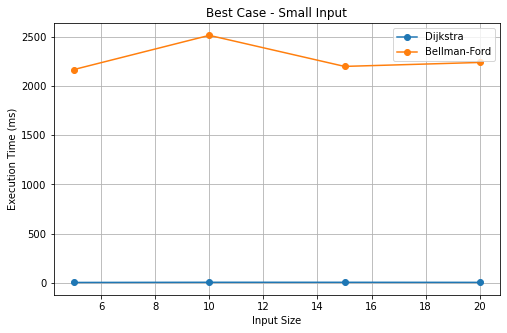

In [29]:
import matplotlib.pyplot as plt

# Small input sizes
small_sizes = [5, 10, 15, 20]

# Dijkstra averages
dijkstra_small = [4.104184, 5.838306, 5.682575, 4.995337]

# Bellman-Ford averages
bellman_small = [2168.280481, 2515.509706, 2199.913664, 2240.018653]

# Plot
plt.figure(figsize=(8,5))

plt.plot(small_sizes, dijkstra_small, marker='o', label='Dijkstra')
plt.plot(small_sizes, bellman_small, marker='o', label='Bellman-Ford')

# Labels
plt.title("Best Case - Small Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")

plt.legend()
plt.grid(True)

plt.show()

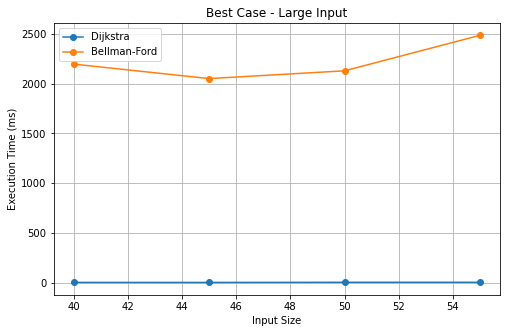

In [30]:
import matplotlib.pyplot as plt

# Large input sizes
large_sizes = [40, 45, 50, 55]

# Dijkstra averages
dijkstra_large = [4.498860, 4.133455, 5.614082, 5.526842]

# Bellman-Ford averages
bellman_large = [2196.147600, 2051.217327, 2129.223360, 2485.332119]

# Plot
plt.figure(figsize=(8,5))

plt.plot(large_sizes, dijkstra_large, marker='o', label='Dijkstra')
plt.plot(large_sizes, bellman_large, marker='o', label='Bellman-Ford')

# Labels
plt.title("Best Case - Large Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")

plt.legend()
plt.grid(True)

plt.show()

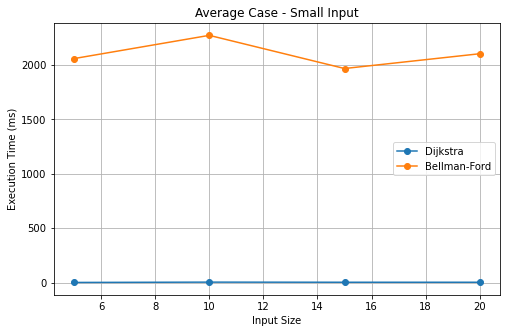

In [1]:
import matplotlib.pyplot as plt

small_sizes = [5, 10, 15, 20]

dijkstra_avg_small = [1.983611, 4.844510, 3.795666, 3.752707]
bellman_avg_small = [2057.515394, 2270.890691, 1966.411329, 2102.162244]

plt.figure(figsize=(8,5))
plt.plot(small_sizes, dijkstra_avg_small, marker='o', label='Dijkstra')
plt.plot(small_sizes, bellman_avg_small, marker='o', label='Bellman-Ford')

plt.title("Average Case - Small Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

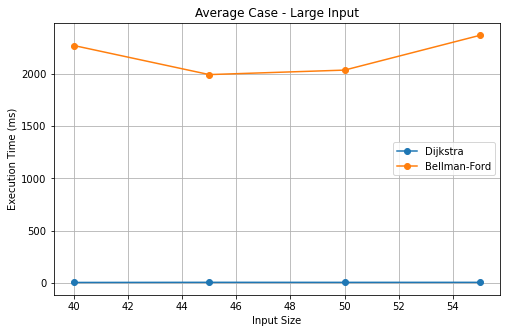

In [2]:
import matplotlib.pyplot as plt

large_sizes = [40, 45, 50, 55]

dijkstra_avg_large = [2.010866, 3.203593, 2.873070, 3.051804]
bellman_avg_large = [2273.476548, 1995.031779, 2037.994238, 2371.241599]

plt.figure(figsize=(8,5))
plt.plot(large_sizes, dijkstra_avg_large, marker='o', label='Dijkstra')
plt.plot(large_sizes, bellman_avg_large, marker='o', label='Bellman-Ford')

plt.title("Average Case - Large Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

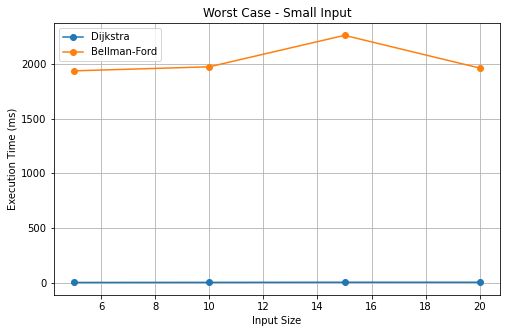

In [3]:
import matplotlib.pyplot as plt

small_sizes = [5, 10, 15, 20]

dijkstra_worst_small = [2.517304, 3.289650, 4.381435, 4.278355]
bellman_worst_small = [1935.478229, 1972.643757, 2259.840399, 1960.901526]

plt.figure(figsize=(8,5))
plt.plot(small_sizes, dijkstra_worst_small, marker='o', label='Dijkstra')
plt.plot(small_sizes, bellman_worst_small, marker='o', label='Bellman-Ford')

plt.title("Worst Case - Small Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

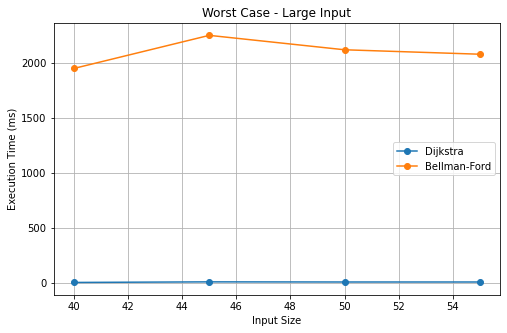

In [4]:
import matplotlib.pyplot as plt

large_sizes = [40, 45, 50, 55]

dijkstra_worst_large = [0.507465, 5.843900, 4.558384, 4.564631]
bellman_worst_large = [1952.816882, 2254.466690, 2122.923949, 2082.380546]

plt.figure(figsize=(8,5))
plt.plot(large_sizes, dijkstra_worst_large, marker='o', label='Dijkstra')
plt.plot(large_sizes, bellman_worst_large, marker='o', label='Bellman-Ford')

plt.title("Worst Case - Large Input")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.legend()
plt.grid(True)
plt.show()